<a href="https://colab.research.google.com/github/hpdiaz2000-ux/hpdiaz2000-ux/blob/main/telco_churn_modelos_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Churn: comparacion de modelos de clasificacion


- Carga de datos Telco Churn desde URL
- Preprocesamiento
- Entrenamiento de multiples modelos: AdaBoost, Random Forest, KNN, DT, Regresion Logistica, CatBoost, XGBoost, GradientBoosting y LightGBM
- Matriz de confusion y metricas (accuracy, precision, recall, F1, AUC, etc.)
- Curva ROC y AUC por modelo
- Interpretacion final


> Nota: algunas librerias (CatBoost, XGBoost, LightGBM) son opcionales. Si no estan instaladas, el notebook continua con los modelos disponibles.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
)

from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Importacion opcional de modelos externos
catboost_disponible = True
xgboost_disponible = True
lightgbm_disponible = True

try:
    from catboost import CatBoostClassifier
except Exception:
    catboost_disponible = False

try:
    from xgboost import XGBClassifier
except Exception:
    xgboost_disponible = False

try:
    from lightgbm import LGBMClassifier
except Exception:
    lightgbm_disponible = False

print('CatBoost disponible:', catboost_disponible)
print('XGBoost disponible:', xgboost_disponible)
print('LightGBM disponible:', lightgbm_disponible)

CatBoost disponible: False
XGBoost disponible: True
LightGBM disponible: True


## 1) Cargar Telco Churn desde URL

In [ ]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2) Limpieza y preprocesamiento

- `TotalCharges` viene como texto en algunos casos y se convierte a numerico.
- Se elimina `customerID` por ser un identificador.
- La variable objetivo `Churn` se pasa a 0/1.

In [ ]:
# Copia para no modificar el original
data = df.copy()

# Convertir TotalCharges a numerico
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Eliminar nulos que salgan de la conversion
data = data.dropna().reset_index(drop=True)

# Eliminar ID
if 'customerID' in data.columns:
    data = data.drop(columns=['customerID'])

# Target a 0/1
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

print('Shape despues de limpieza:', data.shape)
data.head()

Shape despues de limpieza: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Prevalencia de clases:


,conteo,proporcion
Clase negativa (0: No churn),5163,0.734215
Clase positiva (1: Churn),1869,0.265785


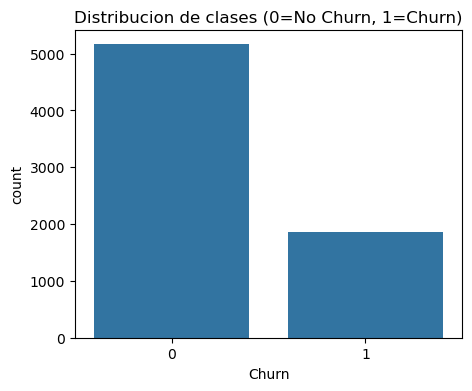

In [ ]:
# Distribucion de clases (prevalencia)
conteo = data['Churn'].value_counts().sort_index()
prevalencia = data['Churn'].value_counts(normalize=True).sort_index()

resumen_clases = pd.DataFrame({
    'conteo': conteo,
    'proporcion': prevalencia
})
resumen_clases.index = ['Clase negativa (0: No churn)', 'Clase positiva (1: Churn)']

print('Prevalencia de clases:')
display(resumen_clases)

plt.figure(figsize=(5,4))
sns.countplot(x=data['Churn'])
plt.title('Distribucion de clases (0=No Churn, 1=Churn)')
plt.show()

## 3) Separar X/y y dividir train-test

In [ ]:
X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (5274, 19) Test: (1758, 19)


In [ ]:
# Columnas numericas y categoricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numericas:', len(numeric_features))
print('Categoricas:', len(categorical_features))

# Preprocesador: escalar numericas + one-hot categoricas
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

Numericas: 4
Categoricas: 15


## 4) Definir modelos

In [ ]:
modelos = {
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree (DT)': DecisionTreeClassifier(random_state=42),
    'Regresion Logistica': LogisticRegression(max_iter=2000, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

if catboost_disponible:
    modelos['CatBoost'] = CatBoostClassifier(verbose=0, random_state=42)

if xgboost_disponible:
    modelos['XGBoost'] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42,
    )

if lightgbm_disponible:
    modelos['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
    )

print('Modelos a entrenar:')
for m in modelos:
    print('-', m)

Modelos a entrenar:
- AdaBoost
- Random Forest
- KNN
- Decision Tree (DT)
- Regresion Logistica
- GradientBoosting
- XGBoost
- LightGBM


## 5) Entrenamiento y metricas

Metricas incluidas:
- Accuracy
- Precision clase positiva (1)
- Precision clase negativa (0)
- Recall (sensibilidad)
- Specificity (recall de clase negativa)
- F1 score
- Balanced Accuracy
- ROC AUC

In [ ]:
resultados = []
conf_matrices = {}
roc_curvas = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ('prep', preprocess),
        ('model', modelo)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    # Probabilidades para ROC/AUC
    if hasattr(pipe, 'predict_proba'):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        # fallback por si algun modelo no tuviera predict_proba
        scores = pipe.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[nombre] = cm

    tn, fp, fn, tp = cm.ravel()

    # Precision de clase positiva y negativa
    precision_pos = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    precision_neg = precision_score(y_test, y_pred, pos_label=0, zero_division=0)

    # Recall clase positiva (sensibilidad) y clase negativa (specificity)
    recall_pos = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    specificity = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_modelo = roc_auc_score(y_test, y_proba)
    roc_curvas[nombre] = (fpr, tpr, auc_modelo)

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_positiva': precision_pos,
        'Precision_negativa': precision_neg,
        'Recall_positivo': recall_pos,
        'Specificity_negativa': specificity,
        'F1_score': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'ROC_AUC': auc_modelo,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
    })

resultados_df = pd.DataFrame(resultados).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
resultados_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision_positiva': '{:.4f}',
    'Precision_negativa': '{:.4f}',
    'Recall_positivo': '{:.4f}',
    'Specificity_negativa': '{:.4f}',
    'F1_score': '{:.4f}',
    'Balanced_Accuracy': '{:.4f}',
    'ROC_AUC': '{:.4f}',
})

[LightGBM] [Info] Number of positive: 1402, number of negative: 3872
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 5274, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265832 -> initscore=-1.015871
[LightGBM] [Info] Start training from score -1.015871


,Modelo,Accuracy,Precision_positiva,Precision_negativa,Recall_positivo,Specificity_negativa,F1_score,Balanced_Accuracy,ROC_AUC,TP,FP,FN,TN
0,AdaBoost,0.7986,0.6445,0.8427,0.5396,0.8923,0.5874,0.7160,0.8406,252,139,215,1152
1,Regresion Logistica,0.8066,0.6553,0.8525,0.5739,0.8908,0.6119,0.7323,0.8402,268,141,199,1150
2,GradientBoosting,0.7941,0.6408,0.8354,0.5118,0.8962,0.5690,0.7040,0.8399,239,134,228,1157
3,XGBoost,0.7907,0.6313,0.8342,0.5096,0.8923,0.5640,0.7010,0.8351,238,139,229,1152
4,LightGBM,0.7787,0.5995,0.8302,0.5032,0.8784,0.5471,0.6908,0.8245,235,157,232,1134
5,KNN,0.7810,0.5903,0.8474,0.5739,0.8559,0.5820,0.7149,0.8168,268,186,199,1105
6,Random Forest,0.7838,0.6192,0.8270,0.4839,0.8923,0.5433,0.6881,0.8117,226,139,241,1152
7,Decision Tree (DT),0.7258,0.4843,0.8158,0.4946,0.8095,0.4894,0.6520,0.6515,231,246,236,1045


## 6) Matriz de confusion por modelo

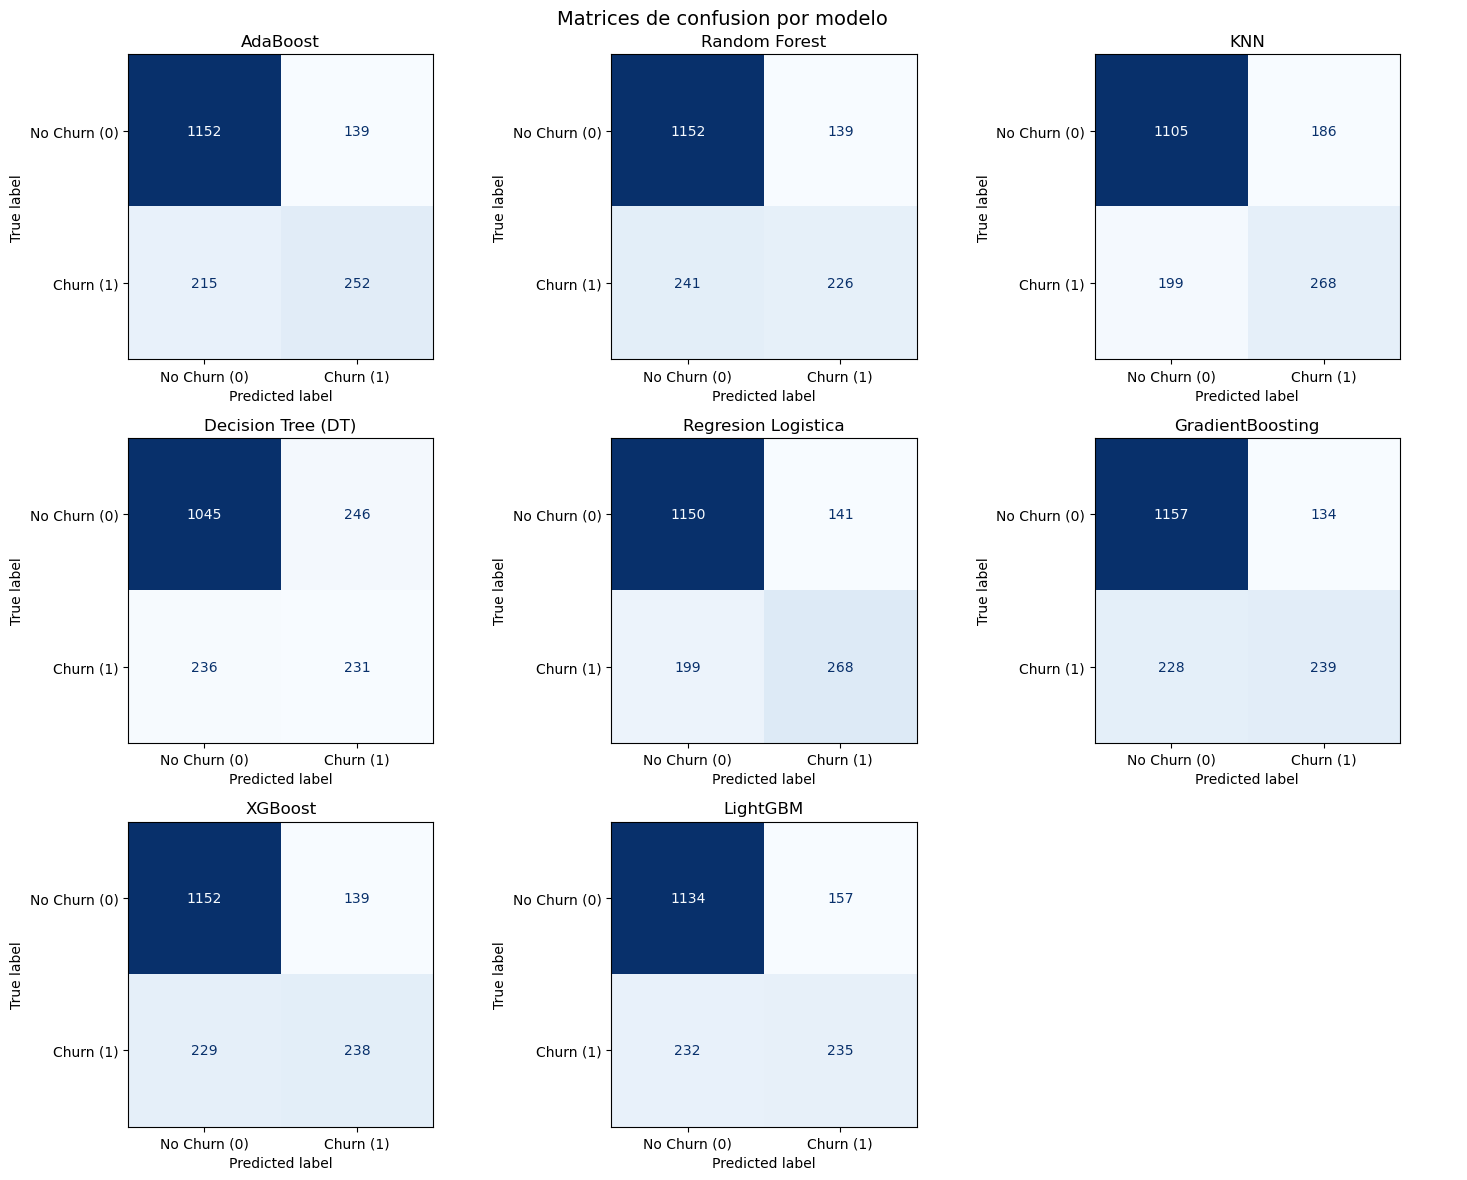

In [ ]:
n_modelos = len(conf_matrices)
cols = 3
rows = int(np.ceil(n_modelos / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, (nombre, cm) in enumerate(conf_matrices.items()):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(nombre)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Matrices de confusion por modelo', fontsize=14)
plt.tight_layout()
plt.show()

## 7) Curvas ROC y AUC por modelo

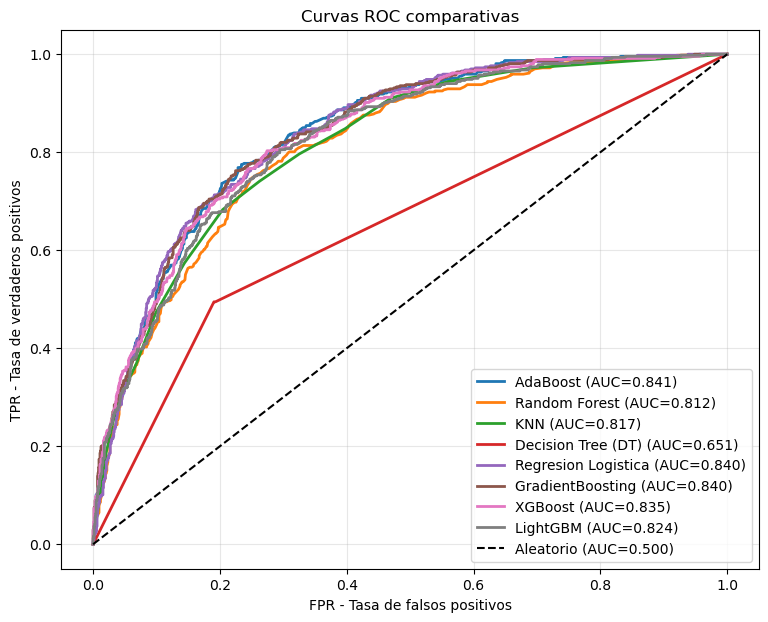

In [ ]:
plt.figure(figsize=(9, 7))

for nombre, (fpr, tpr, auc_modelo) in roc_curvas.items():
    plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC={auc_modelo:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.500)')
plt.xlabel('FPR - Tasa de falsos positivos')
plt.ylabel('TPR - Tasa de verdaderos positivos')
plt.title('Curvas ROC comparativas')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 8) Conclusiones para clase

- El mejor modelo depende de la metrica objetivo (AUC, F1, recall, etc.).
- Si importa no perder churners, prioriza **Recall positivo**.
- Si importa reducir falsas alarmas, revisa **Precision positiva** y **Specificity**.
- El AUC ayuda a comparar modelos de forma global sin fijar un umbral unico.

In [ ]:
top_auc = resultados_df.iloc[0]
print('Mejor modelo por ROC_AUC:', top_auc['Modelo'])
print(f"AUC: {top_auc['ROC_AUC']:.4f}")
print(f"F1: {top_auc['F1_score']:.4f}")
print(f"Recall positivo: {top_auc['Recall_positivo']:.4f}")
print(f"Precision positiva: {top_auc['Precision_positiva']:.4f}")

Mejor modelo por ROC_AUC: AdaBoost
AUC: 0.8406
F1: 0.5874
Recall positivo: 0.5396
Precision positiva: 0.6445
